In [1]:
# read the data
import matplotlib.pyplot as plt
import numpy as np
#import pandas as pd 
import matplotlib
import sys     
import mne     
import os
from mne.preprocessing import ICA
from scipy import stats
import seaborn as sns
import pandas as pd
#%matplotlib qt
sys.path.append(os.path.abspath('..'))
from utils import identify_bad_channels,remove_epochs_with_bad_mmn_channels, Average_in_trials_in_time_window,remove_or_interpolate_epochs_with_n_bad_chn
from stats_utils import extract_mmn_latencies,align_and_standardize_evokeds,extract_peak_amplitude,extract_mean_amplitudes
from visualization import plot_erps
#, #

In [2]:
folder = r"E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched"
sub = 'sub-sd042'
epochs = mne.read_epochs(f'{os.path.join(folder,sub)}-epo.fif', preload=True)

Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd042-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
2402 matching events found
No baseline correction applied
0 projection items activated


In [3]:
PN_devi_eps = epochs['S15'].average()
BN_sta_eps = epochs['S14'].average()

BN_devi_eps = epochs['S25'].average() 
PN_sta_eps = epochs['S24'].average() 

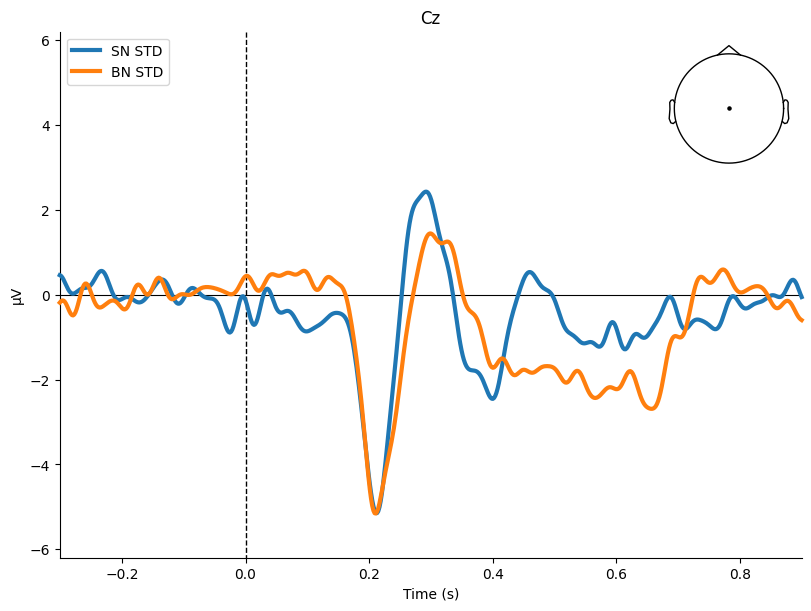

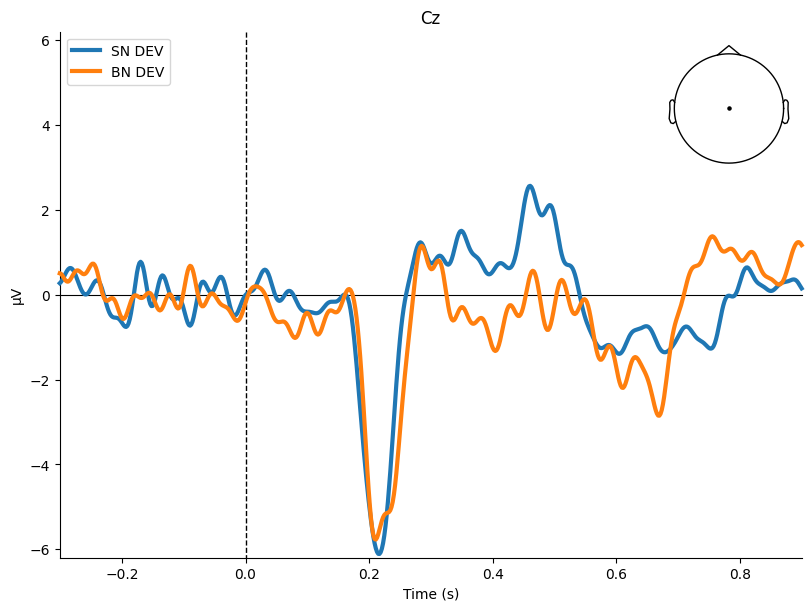

[<Figure size 800x600 with 2 Axes>]

In [4]:
evokeds = { 
    "SN STD" :PN_sta_eps ,
    'BN STD':BN_sta_eps,
    # "CN STD" : mne.combine_evoked([ CN_devi_eps,CN_sta_eps], weights=[1,-1]),
           }

stylesdict ={"SN STD": {"linewidth": 3,"linestyle":'solid'},
             "BN STD" : {"linewidth": 3,"linestyle":'solid'},
            #  "CN MMN" : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds,styles = stylesdict,
                             truncate_xaxis=False,truncate_yaxis=False,picks=['Cz'],
                             ylim = dict(eeg=[-6.2,6.2]))

evokeds = { 
    "SN DEV" :PN_devi_eps  ,
    'BN DEV':BN_devi_eps,
    # "CN STD" : mne.combine_evoked([ CN_devi_eps,CN_sta_eps], weights=[1,-1]),
           }

stylesdict ={"SN DEV": {"linewidth": 3,"linestyle":'solid'},
             "BN DEV" : {"linewidth": 3,"linestyle":'solid'},
            #  "CN MMN" : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds,styles = stylesdict,
                             truncate_xaxis=False,truncate_yaxis=False,picks=['Cz'],
                             ylim = dict(eeg=[-6.2,6.2]))

In [5]:
import numpy as np

def bootstrap_epochs(epochs, n_boot, random_state=None):
    """
    Randomly select epochs with replacement and return them as an MNE Epochs object.

    Parameters
    ----------
    epochs : mne.Epochs
        The original epoched EEG data.
    n_boot : int
        Number of epochs to sample (with replacement).
    random_state : int | None
        Seed for reproducibility.

    Returns
    -------
    boot_epochs : mne.Epochs
        New Epochs object containing the bootstrapped selection.
    """
    rng = np.random.default_rng(random_state)
    n_trials = len(epochs)

    # sample trial indices with replacement
    idx = rng.integers(0, n_trials, size=n_boot)

    # use MNE indexing to get a new Epochs object
    boot_epochs = epochs[idx]

    return boot_epochs


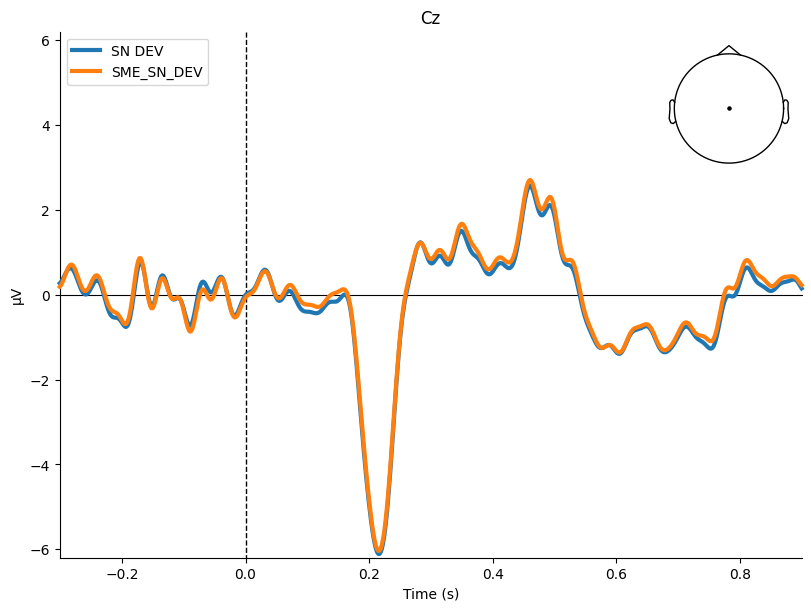

[<Figure size 800x600 with 2 Axes>]

In [6]:
# Get 30 random epochs with replacement
SME_SN_DEV = bootstrap_epochs(epochs['S15'], n_boot=10000, random_state=42)

evokeds = { 
    "SN DEV" :PN_devi_eps  ,
    'SME_SN_DEV':SME_SN_DEV.average(),
    # "CN STD" : mne.combine_evoked([ CN_devi_eps,CN_sta_eps], weights=[1,-1]),
           }

stylesdict ={"SN DEV": {"linewidth": 3,"linestyle":'solid'},
             "SME_SN_DEV" : {"linewidth": 3,"linestyle":'solid'},
            #  "CN MMN" : {"linewidth": 3,"linestyle":'solid'},
             }
mne.viz.plot_compare_evokeds(evokeds,styles = stylesdict,
                             truncate_xaxis=False,truncate_yaxis=False,picks=['Cz'],
                             ylim = dict(eeg=[-6.2,6.2]))      # 30 epochs


In [7]:
len(epochs["S15"])

140

In [8]:
import numpy as np
import mne

def erp_measures(evoked, tmin=0.1, tmax=0.25, picks=None, frac=0.5, polarity="neg"):
    """
    Compute ERP measures (mean amplitude, peak amplitude, peak latency,
    and fractional latency) for an Evoked object in a given time window.
    
    Parameters
    ----------
    evoked : mne.Evoked
        Averaged ERP waveform.
    tmin, tmax : float
        Time window in seconds (default 0.1–0.25s).
    picks : list | str | None
        Channels to include (default: all).
    frac : float
        Fraction for fractional latency (0–1).
    polarity : str
        "neg" for negative peak, "pos" for positive peak.
    
    Returns
    -------
    results : dict
        {
            "mean_amplitude": float,
            "peak_amplitude": float,
            "peak_latency": float,
            "fractional_latency": float
        }
    """
    # Crop to the time window
    evk = evoked.copy().crop(tmin=tmin, tmax=tmax).pick(picks)
    
    # Extract data and times
    data = evk.data.mean(axis=0)   # average across channels
    times = evk.times

    # Mean amplitude
    mean_amp = data.mean()

    # Peak amplitude + latency (depending on polarity)
    if polarity == "neg":
        peak_amp = data.min()
        peak_idx = data.argmin()
        threshold = frac * peak_amp  # closer to zero (less negative)
        frac_mask = np.where(data <= threshold)[0]
    elif polarity == "pos":
        peak_amp = data.max()
        peak_idx = data.argmax()
        threshold = frac * peak_amp
        frac_mask = np.where(data >= threshold)[0]
    else:
        raise ValueError("polarity must be 'neg' or 'pos'")

    peak_lat = times[peak_idx]

    # Fractional latency
    frac_lat = times[frac_mask[0]] if frac_mask.size > 0 else np.nan

    return {
        "mean_amplitude": mean_amp,
        "peak_amplitude": peak_amp,
        "peak_latency": peak_lat,
        "fractional_latency": frac_lat
    }


In [9]:
import numpy as np

def epochs_measures(epochs, tmin=0.1, tmax=0.25, picks=None, frac=0.5, polarity="neg"):
    """
    Compute ERP measures (mean amplitude, peak amplitude, peak latency,
    and fractional latency) for EACH epoch in an Epochs object,
    returning lists of values grouped by measure.

    Parameters
    ----------
    epochs : mne.Epochs
        Single-trial EEG data.
    tmin, tmax : float
        Time window in seconds (default 0.1–0.25s).
    picks : list | str | None
        Channels to include (default: all).
    frac : float
        Fraction for fractional latency (0–1).
    polarity : str
        "neg" for negative peak, "pos" for positive peak.

    Returns
    -------
    results : dict
        {
            "mean_amplitude": [..],
            "peak_amplitude": [..],
            "peak_latency": [..],
            "fractional_latency": [..]
        }
    """
    # Pick and crop epochs
    ep = epochs.copy().pick(picks).crop(tmin=tmin, tmax=tmax)
    data = ep.get_data(copy=False)  # shape: (n_epochs, n_channels, n_times)
    times = ep.times

    mean_amplitudes = []
    peak_amplitudes = []
    peak_latencies = []
    fractional_latencies = []

    for e in data:
        # Average across channels
        sig = e.mean(axis=0)

        # Mean amplitude
        mean_amp = sig.mean()

        # Peak amplitude + latency
        if polarity == "neg":
            peak_amp = sig.min()
            peak_idx = sig.argmin()
            threshold = frac * peak_amp  # closer to zero (less negative)
            frac_mask = np.where(sig <= threshold)[0]
        elif polarity == "pos":
            peak_amp = sig.max()
            peak_idx = sig.argmax()
            threshold = frac * peak_amp
            frac_mask = np.where(sig >= threshold)[0]
        else:
            raise ValueError("polarity must be 'neg' or 'pos'")

        peak_lat = times[peak_idx]

        # Fractional latency
        frac_lat = times[frac_mask[0]] if frac_mask.size > 0 else np.nan

        # Append
        mean_amplitudes.append(mean_amp)
        peak_amplitudes.append(peak_amp)
        peak_latencies.append(peak_lat)
        fractional_latencies.append(frac_lat)

    return {
        "mean_amplitude": mean_amplitudes,
        "peak_amplitude": peak_amplitudes,
        "peak_latency": peak_latencies,
        "fractional_latency": fractional_latencies
    }


In [10]:
sub_SME = dict()

for n_boot in range(10,5000,10):
    measures_dict = {
        "mean_amplitude": [],
        "peak_amplitude": [],
        "peak_latency": [],
        "fractional_latency": []
    }
    print("Number of boot: ",n_boot)
    # for i in range(n_iter):
    #     # bootstrap selection of epochs 
    #     SME_SN_DEV = bootstrap_epochs(epochs['S15'], n_boot=n_boot  )
    #     SME_DEV_eps = SME_SN_DEV.average()

    #     # compute measures
    #     neg_results = erp_measures(
    #         SME_DEV_eps,
    #         tmin=0.15, tmax=0.25,
    #         picks="Cz",
    #         frac=0.25,
    #         polarity="neg"
    #     )
    #     # append each measure to the lists
    #     for key in measures_dict.keys():
    #         measures_dict[key].append(neg_results[key])
  
    # assign the lists of values to sub_SME for this n_boot
    SME_SN_DEV_epochs = bootstrap_epochs(epochs['S15'], n_boot=n_boot )
    measures_dict = epochs_measures(SME_SN_DEV_epochs, tmin=0.15, tmax=0.25, picks=None, frac=0.5, polarity="neg")
    sub_SME[n_boot] = measures_dict

Number of boot:  10
Number of boot:  20
Number of boot:  30
Number of boot:  40
Number of boot:  50
Number of boot:  60
Number of boot:  70
Number of boot:  80
Number of boot:  90
Number of boot:  100
Number of boot:  110
Number of boot:  120
Number of boot:  130
Number of boot:  140
Number of boot:  150
Number of boot:  160
Number of boot:  170
Number of boot:  180
Number of boot:  190
Number of boot:  200
Number of boot:  210
Number of boot:  220
Number of boot:  230
Number of boot:  240
Number of boot:  250
Number of boot:  260
Number of boot:  270
Number of boot:  280
Number of boot:  290
Number of boot:  300
Number of boot:  310
Number of boot:  320
Number of boot:  330
Number of boot:  340
Number of boot:  350
Number of boot:  360
Number of boot:  370
Number of boot:  380
Number of boot:  390
Number of boot:  400
Number of boot:  410
Number of boot:  420
Number of boot:  430
Number of boot:  440
Number of boot:  450
Number of boot:  460
Number of boot:  470
Number of boot:  480
N

In [ ]:
import matplotlib.pyplot as plt

def plot_all_subjects(all_SME):
    """
    Plot n_boot vs ERP measures for multiple subjects.
    Each row corresponds to one subject, with 4 subplots per row.
    
    Parameters
    ----------
    all_SME : dict
        Dictionary of subjects, e.g.,
        {
            "sub1": sub_SME1,
            "sub2": sub_SME2,
            ...
        }
        where each sub_SME is itself a dict of {n_boot: measures}. b
    """
    n_subs = len(all_SME)
    fig, axs = plt.subplots(n_subs, 4, figsize=(18, 4 * n_subs), sharex=False)

    if n_subs == 1:
        axs = axs.reshape(1, -1)  # ensure 2D array for single subject

    for row, (sub, sub_SME) in enumerate(all_SME.items()):
        n_boots = list(sub_SME.keys())
        mean_amplitudes = [np.nanstd(v['mean_amplitude'], ddof=1) / np.sqrt(n)
                for n, v in sub_SME.items()]
        peak_amplitudes = [np.nanstd(v['peak_amplitude'], ddof=1) / np.sqrt(n)
                for n, v in sub_SME.items()]
        peak_latencies =[np.nanstd(v['peak_latency'], ddof=1) / np.sqrt(n) 
                for n, v in sub_SME.items()] 
        fractional_latencies = [np.nanstd(v['fractional_latency'], ddof=1) / np.sqrt(n)
                for n, v in sub_SME.items()] 
        # Mean amplitude
        axs[row, 0].plot(n_boots, mean_amplitudes, marker='o')
        axs[row, 0].set_title(f"{sub} - Mean Amp")
        axs[row, 0].set_ylabel("SME")

        # Peak amplitude
        axs[row, 1].plot(n_boots, peak_amplitudes, marker='o', color='orange')
        axs[row, 1].set_title(f"{sub} - Peak Amp")

        # Peak latency
        axs[row, 2].plot(n_boots, peak_latencies, marker='o', color='green')
        axs[row, 2].set_title(f"{sub} - Peak Lat")

        # Fractional latency
        axs[row, 3].plot(n_boots, fractional_latencies, marker='o', color='red')
        axs[row, 3].set_title(f"{sub} - Fractional Lat")
        axs[row, 3].set_xlabel("n_boot")

    plt.tight_layout()
    plt.show()


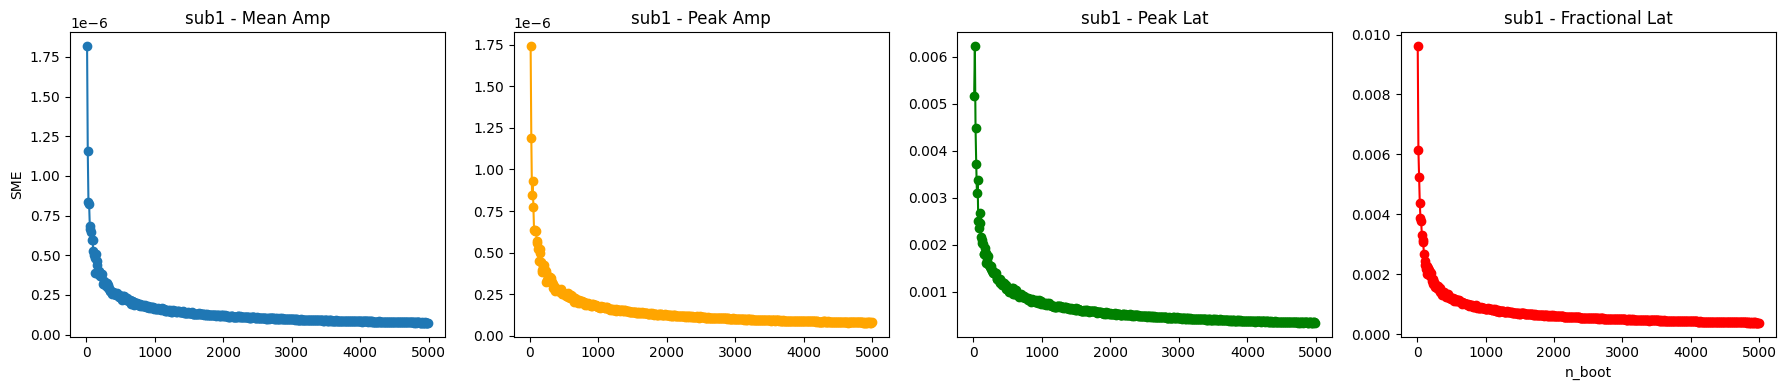

In [12]:
all_SME = {
    "sub1": sub_SME,   # dict for subject 1
    # ...
}

plot_all_subjects(all_SME)


In [ ]:
N1_STD_peak_sub = [11, 12, 17, 18,19, 21, 24, 25, 26, 29, 30 ,
                    31, 32, 33 , 35,  36 ,37, 38,39,40,41,42,44,
                    45, 46, 47 ,49]
folder = r"E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched"
all_SME = dict()

for sub_id in N1_STD_peak_sub:
    sub = 'sub-sd0'+str(sub_id) 
    print(sub)
    epochs = mne.read_epochs(f'{os.path.join(folder,sub)}-epo.fif', preload=True)
    sub_SME = dict()
    for n_boot in range(10,5010,10):
        measures_dict = {
            "mean_amplitude": [],
            "peak_amplitude": [],
            "peak_latency": [],
            "fractional_latency": [] }
        
        print("Number of boot: ",n_boot)
        SME_SN_DEV_epochs = bootstrap_epochs(epochs['S15'], n_boot=n_boot )
        measures_dict = epochs_measures(SME_SN_DEV_epochs, tmin=0.15, tmax=0.25, picks=None, frac=0.5, polarity="neg")
        sub_SME[n_boot] = measures_dict
    all_SME[sub]= sub_SME

sub-sd011
Reading E:\ecf-exp2-notif-mmn\data\Processed\preprocessed_epoched\sub-sd011-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1291 matching events found
No baseline correction applied
0 projection items activated
Number of boot:  10
Number of boot:  20
Number of boot:  30
Number of boot:  40
Number of boot:  50
Number of boot:  60
Number of boot:  70
Number of boot:  80
Number of boot:  90
Number of boot:  100
Number of boot:  110
Number of boot:  120
Number of boot:  130
Number of boot:  140
Number of boot:  150
Number of boot:  160
Number of boot:  170
Number of boot:  180
Number of boot:  190
Number of boot:  200
Number of boot:  210
Number of boot:  220
Number of boot:  230
Number of boot:  240
Number of boot:  250
Number of boot:  260
Number of boot:  270
Number of boot:  280
Number of boot:  290
Number of boot:  300
Number of boot:  310
Number of boot:  320
Number of bo

In [ ]:
all_SME

NameError: name 'all_SME' is not defined